In [40]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import CMR_IA as cmr
import scipy as sp
import sys

sys.path.append("../../Modeling/fitting")
from optimization_utils import make_boundary, param_vec_to_dict

In [41]:
# plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 16
SAVEFIG = False
SAVERES = False

## Load Stimuli and Semantic Matrix

In [42]:
with open("simu7_data/simu7_design.pkl", "rb") as inp:
    df_study = pickle.load(inp)
    df_test = pickle.load(inp)
# df_study = df_study.loc[df_study.session < 500]  # for testing
# df_test = df_test.loc[df_test.session < 500]  # for testing

In [43]:
df_study

,study_itemno1,study_itemno2,study_item1,study_item2,serial_pos,list,session
0,110,1083,BED,PLANT,0,0,0
1,1262,1627,SEAL,WRITER,1,0,0
2,738,1198,INMATE,ROBE,2,0,0
3,187,748,BUG,JAM,3,0,0
4,1423,1072,SWORD,PIN,4,0,0
...,...,...,...,...,...,...,...
191995,187,1314,BUG,SKELETON,7,15,999
191996,1438,1433,TAXI,TAPE,8,15,999
191997,1537,1489,UNDERWEAR,TOWEL,9,15,999
191998,386,283,COUCH,CHAUFFEUR,10,15,999


In [44]:
df_test

,test_itemno,test_item,correct_ans,study_pos,test_dir,list,session
0,324,CLIPPERS,823,9,1,0,0
1,1347,SPARROW,1051,8,1,0,0
2,413,CROSS,524,7,0,0,0
3,812,LEOPARD,1323,5,0,0,0
4,110,BED,1083,0,0,0,0
...,...,...,...,...,...,...,...
127995,947,NEUTRON,402,11,0,15,999
127996,467,DINER,1441,2,1,15,999
127997,1444,TEENAGER,1014,4,0,15,999
127998,1489,TOWEL,1537,9,1,15,999


In [45]:
s_mat = np.load("../wordpools/ltp_FR_similarity_matrix.npy")

## Run CMR-IA

In [46]:
# define parameters
params = cmr.make_default_params()
params.update(use_new_context=True, nitems_in_accumulator=96)

# load pso results
_, _, what_to_fit = make_boundary(sim_name="7")
optim_params = np.loadtxt("simu7_data/7_250311_200-200.txt")
for pname, pvalue in zip(what_to_fit, optim_params):
    params[pname] = pvalue
params

{'beta_enc': 0.845814,
 'beta_rec': 0.083332,
 'beta_cue': 0.693018,
 'beta_rec_post': 0.224431,
 'beta_distract': 0.219932,
 'phi_s': 1.496335,
 'phi_d': 0.013195,
 's_cf': 0.346849,
 's_fc': 0.3027,
 'kappa': 0.050411,
 'eta': 0.022039,
 'omega': 7.914679,
 'alpha': 0.961427,
 'lamb': 0.14727,
 'c_thresh': 0.364359,
 'c_thresh_itm': 0.5,
 'c_thresh_assoc': 0.5,
 'd_assoc': 1,
 'rec_time_limit': 60000.0,
 'dt': 10,
 'nitems_in_accumulator': 96,
 'max_recalls': 50,
 'learn_while_retrieving': False,
 'use_new_context': True,
 'psi_s': 0,
 'psi_c': 1,
 'c_s': 0,
 'thresh_sigma': 0,
 'ban_recall': None,
 'var_enc': 1,
 'bad_enc_ratio': 1,
 'recog_slope': 1,
 'a': 2800,
 'b': 20,
 'gamma_fc': 0.776299,
 'gamma_cf': 0.488009}

In [47]:
# # define parameters
# params = cmr.make_default_params()
# params.update(
#     beta_enc=0.6,  # 0.6
#     beta_rec=0.1,
#     beta_cue=0.6,
#     beta_distract=0.1,
#     beta_rec_post=0.1,
#     gamma_fc=0.55,  # 0.4
#     gamma_cf=0.7,  # 0.6, cf - fc Higher, ILI +1 Higher
#     s_fc=0.15,  # 0.2
#     s_cf=0.15,  # 0.2
#     c_thresh=0.2,  # 0.01
#     kappa=0.04,  # 0.05
#     lamb=0.01,  # 0.02
#     eta=0.02,  # 0.02, raise it can diminish the diff between +1 and +2
#     omega=5,  # this is important for increasing PLI num
#     alpha=1,
#     phi_s=0.25,  # 0.3, control the plateau of left and right side of ILI
#     phi_d=0.5,
#     nitems_in_accumulator=96,  # 48
#     use_new_context=True,
# )
# params

In [48]:
# run CMR-IA
df_simu, f_in, f_dif = cmr.run_norm_cr_multi_sess(params, df_study, df_test, s_mat)
df_simu

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [08:51<00:00,  1.88it/s]

CMR Time: 531.151859998703


,session,list,test_itemno,s_resp,s_rt,csim
0,0,0,324,823.0,1390.0,0.893475
1,0,0,1347,1051.0,2210.0,0.901073
2,0,0,413,524.0,1290.0,0.915920
3,0,0,812,1323.0,1410.0,0.905635
4,0,0,110,679.0,1650.0,0.734877
...,...,...,...,...,...,...
127995,999,15,947,402.0,3690.0,0.903579
127996,999,15,467,-1.0,-1.0,-1.000000
127997,999,15,1444,-1.0,-1.0,-1.000000
127998,999,15,1489,1537.0,2800.0,0.926099


In [49]:
# merge to get more info
df_simu = df_simu.merge(df_test, on=["session", "list", "test_itemno"])
df_simu["correct"] = df_simu.s_resp == df_simu.correct_ans
df_simu

,session,list,test_itemno,s_resp,s_rt,csim,test_item,correct_ans,study_pos,test_dir,correct
0,0,0,324,823.0,1390.0,0.893475,CLIPPERS,823,9,1,True
1,0,0,1347,1051.0,2210.0,0.901073,SPARROW,1051,8,1,True
2,0,0,413,524.0,1290.0,0.915920,CROSS,524,7,0,True
3,0,0,812,1323.0,1410.0,0.905635,LEOPARD,1323,5,0,True
4,0,0,110,679.0,1650.0,0.734877,BED,1083,0,0,False
...,...,...,...,...,...,...,...,...,...,...,...
127995,999,15,947,402.0,3690.0,0.903579,NEUTRON,402,11,0,True
127996,999,15,467,-1.0,-1.0,-1.000000,DINER,1441,2,1,False
127997,999,15,1444,-1.0,-1.0,-1.000000,TEENAGER,1014,4,0,False
127998,999,15,1489,1537.0,2800.0,0.926099,TOWEL,1537,9,1,True


In [50]:
if SAVERES:
    df_simu.to_pickle("simu7_data/simu7_result.pkl")

## Analysis

In [51]:
# with open("simu7_data/simu7_result.pkl", "rb") as inp:
#     df_simu = pickle.load(inp)

In [52]:
# get the study list and study pos of response
sessions = np.unique(df_simu.session)
nlist = len(np.unique(df_simu.list))
resp_study_list = []
resp_study_pos = []
for sess in sessions:

    pres_words = df_study.loc[df_study.session == sess, ["study_itemno1", "study_itemno2"]].to_numpy()
    pres_words = np.reshape(pres_words, (nlist, -1, 2))
    responses = df_simu.loc[df_simu.session == sess, "s_resp"]

    for r in responses:
        if r == -1 or r == -2:
            r_list = None
            r_pos = None
        else:
            r_list = np.where(pres_words == r)[0].item()
            r_pos = np.where(pres_words == r)[1].item()
        resp_study_list.append(r_list)
        resp_study_pos.append(r_pos)

df_simu["resp_study_list"] = resp_study_list
df_simu["resp_study_pos"] = resp_study_pos
df_simu

,session,list,test_itemno,s_resp,s_rt,csim,test_item,correct_ans,study_pos,test_dir,correct,resp_study_list,resp_study_pos
0,0,0,324,823.0,1390.0,0.893475,CLIPPERS,823,9,1,True,0.0,9.0
1,0,0,1347,1051.0,2210.0,0.901073,SPARROW,1051,8,1,True,0.0,8.0
2,0,0,413,524.0,1290.0,0.915920,CROSS,524,7,0,True,0.0,7.0
3,0,0,812,1323.0,1410.0,0.905635,LEOPARD,1323,5,0,True,0.0,5.0
4,0,0,110,679.0,1650.0,0.734877,BED,1083,0,0,False,0.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
127995,999,15,947,402.0,3690.0,0.903579,NEUTRON,402,11,0,True,15.0,11.0
127996,999,15,467,-1.0,-1.0,-1.000000,DINER,1441,2,1,False,NaN,NaN
127997,999,15,1444,-1.0,-1.0,-1.000000,TEENAGER,1014,4,0,False,NaN,NaN
127998,999,15,1489,1537.0,2800.0,0.926099,TOWEL,1537,9,1,True,15.0,9.0


In [53]:
# get intrution type
df_simu["list_lag"] = df_simu["resp_study_list"] - df_simu["list"]
df_simu["pos_lag"] = df_simu["resp_study_pos"] - df_simu["study_pos"]


def which_intrusion(x):
    x_list_lag = x["list_lag"]
    x_pos_lag = x["pos_lag"]

    if np.isnan(x_list_lag):
        return "NoResp"
    elif x_list_lag == 0 and x_pos_lag == 0:
        return "Correct"
    elif x_list_lag < 0:
        return "PLI"
    elif x_list_lag == 0 and x_pos_lag != 0:
        return "ILI"
    else:
        return np.nan


df_simu["intrusion_type"] = df_simu.apply(lambda x: which_intrusion(x), axis=1)
df_simu["intrusion_type"] = pd.Categorical(df_simu["intrusion_type"], categories=["NoResp", "Correct", "PLI", "ILI"])
df_simu

,session,list,test_itemno,s_resp,s_rt,csim,test_item,correct_ans,study_pos,test_dir,correct,resp_study_list,resp_study_pos,list_lag,pos_lag,intrusion_type
0,0,0,324,823.0,1390.0,0.893475,CLIPPERS,823,9,1,True,0.0,9.0,0.0,0.0,Correct
1,0,0,1347,1051.0,2210.0,0.901073,SPARROW,1051,8,1,True,0.0,8.0,0.0,0.0,Correct
2,0,0,413,524.0,1290.0,0.915920,CROSS,524,7,0,True,0.0,7.0,0.0,0.0,Correct
3,0,0,812,1323.0,1410.0,0.905635,LEOPARD,1323,5,0,True,0.0,5.0,0.0,0.0,Correct
4,0,0,110,679.0,1650.0,0.734877,BED,1083,0,0,False,0.0,6.0,0.0,6.0,ILI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127995,999,15,947,402.0,3690.0,0.903579,NEUTRON,402,11,0,True,15.0,11.0,0.0,0.0,Correct
127996,999,15,467,-1.0,-1.0,-1.000000,DINER,1441,2,1,False,NaN,NaN,NaN,NaN,NoResp
127997,999,15,1444,-1.0,-1.0,-1.000000,TEENAGER,1014,4,0,False,NaN,NaN,NaN,NaN,NoResp
127998,999,15,1489,1537.0,2800.0,0.926099,TOWEL,1537,9,1,True,15.0,9.0,0.0,0.0,Correct


In [54]:
# clean list 1
df_simu = df_simu.query("list > 0").copy()
df_simu

,session,list,test_itemno,s_resp,s_rt,csim,test_item,correct_ans,study_pos,test_dir,correct,resp_study_list,resp_study_pos,list_lag,pos_lag,intrusion_type
8,0,1,1141,1248.0,1820.0,0.897841,PUMP,1248,10,1,True,1.0,10.0,0.0,0.0,Correct
9,0,1,1540,232.0,1200.0,0.921971,UNIVERSE,232,9,0,True,1.0,9.0,0.0,0.0,Correct
10,0,1,528,1590.0,2070.0,0.919251,EMERALD,1590,8,1,True,1.0,8.0,0.0,0.0,Correct
11,0,1,506,1534.0,2040.0,0.906579,DUNE,1534,11,0,True,1.0,11.0,0.0,0.0,Correct
12,0,1,844,396.0,890.0,0.914969,LOOP,396,5,1,True,1.0,5.0,0.0,0.0,Correct
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127995,999,15,947,402.0,3690.0,0.903579,NEUTRON,402,11,0,True,15.0,11.0,0.0,0.0,Correct
127996,999,15,467,-1.0,-1.0,-1.000000,DINER,1441,2,1,False,NaN,NaN,NaN,NaN,NoResp
127997,999,15,1444,-1.0,-1.0,-1.000000,TEENAGER,1014,4,0,False,NaN,NaN,NaN,NaN,NoResp
127998,999,15,1489,1537.0,2800.0,0.926099,TOWEL,1537,9,1,True,15.0,9.0,0.0,0.0,Correct


In [55]:
# check response types
df_simu.groupby("intrusion_type")["list"].count()

intrusion_type
NoResp     31551
Correct    81024
PLI         1978
ILI         5447
Name: list, dtype: int64

In [56]:
df_simu.query("s_resp == -1").shape, df_simu.query("s_resp == -2").shape

((31551, 16), (0, 16))

### Overall Prob

In [57]:
df_cnt = df_simu.groupby(["session", "intrusion_type"]).s_resp.count().to_frame(name="count").reset_index()

In [58]:
# check correct
df_cnt_correct = df_cnt.query("intrusion_type == 'Correct'").copy()
df_cnt_correct["total"] = df_simu.groupby("session").test_item.count().tolist()
df_cnt_correct["p"] = df_cnt_correct["count"] / df_cnt_correct["total"]
df_cnt_correct

,session,intrusion_type,count,total,p
1,0,Correct,77,120,0.641667
5,1,Correct,74,120,0.616667
9,2,Correct,88,120,0.733333
13,3,Correct,80,120,0.666667
17,4,Correct,81,120,0.675000
...,...,...,...,...,...
3981,995,Correct,82,120,0.683333
3985,996,Correct,81,120,0.675000
3989,997,Correct,85,120,0.708333
3993,998,Correct,69,120,0.575000


In [59]:
p_correct_mean = np.mean(df_cnt_correct["p"])
p_correct_mean

0.6752

In [60]:
# check ILI
df_cnt_ILI = df_cnt.query("intrusion_type == 'ILI'").copy()
df_cnt_ILI["total"] = df_simu.groupby("session").test_item.count().tolist()
df_cnt_ILI["p"] = df_cnt_ILI["count"] / df_cnt_ILI["total"]
df_cnt_ILI

,session,intrusion_type,count,total,p
3,0,ILI,7,120,0.058333
7,1,ILI,6,120,0.050000
11,2,ILI,3,120,0.025000
15,3,ILI,4,120,0.033333
19,4,ILI,6,120,0.050000
...,...,...,...,...,...
3983,995,ILI,4,120,0.033333
3987,996,ILI,9,120,0.075000
3991,997,ILI,9,120,0.075000
3995,998,ILI,8,120,0.066667


In [61]:
p_ILI_mean = np.mean(df_cnt_ILI["p"])
p_ILI_mean

0.045391666666666663

In [62]:
# check PLI
df_cnt_PLI = df_cnt.query("intrusion_type == 'PLI'").copy()
df_cnt_PLI["total"] = df_simu.groupby("session").test_item.count().tolist()
df_cnt_PLI["p"] = df_cnt_PLI["count"] / df_cnt_PLI["total"]
df_cnt_PLI

,session,intrusion_type,count,total,p
2,0,PLI,0,120,0.000000
6,1,PLI,3,120,0.025000
10,2,PLI,1,120,0.008333
14,3,PLI,2,120,0.016667
18,4,PLI,0,120,0.000000
...,...,...,...,...,...
3982,995,PLI,0,120,0.000000
3986,996,PLI,1,120,0.008333
3990,997,PLI,3,120,0.025000
3994,998,PLI,1,120,0.008333


In [63]:
p_PLI_mean = np.mean(df_cnt_PLI["p"])
p_PLI_mean

0.01648333333333333

### PLI

In [64]:
# pick list > 5 and list_lag -5 to -1
df_PLI = df_simu.query("intrusion_type == 'PLI' and list > 5 and list_lag > -6").copy()
df_PLI["abs_list_lag"] = df_PLI["list_lag"].abs().astype(int)
df_PLI["abs_list_lag"] = pd.Categorical(df_PLI["abs_list_lag"], categories=[1, 2, 3, 4, 5], ordered=True)
df_PLI

,session,list,test_itemno,s_resp,s_rt,csim,test_item,correct_ans,study_pos,test_dir,correct,resp_study_list,resp_study_pos,list_lag,pos_lag,intrusion_type,abs_list_lag
203,1,9,753,1106.0,4260.0,0.759257,JEEP,570,4,1,False,7.0,0.0,-2.0,-4.0,PLI,2
251,1,15,1063,1357.0,3870.0,0.779018,PIER,229,8,0,False,13.0,5.0,-2.0,-3.0,PLI,2
322,2,8,523,834.0,4700.0,0.739305,ELEPHANT,1335,9,1,False,4.0,0.0,-4.0,-9.0,PLI,4
453,3,8,924,911.0,4400.0,0.682601,MOUNTAIN,326,1,0,False,5.0,2.0,-3.0,1.0,PLI,3
742,5,12,728,1255.0,1530.0,0.752327,HUSBAND,1314,4,1,False,10.0,2.0,-2.0,-2.0,PLI,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127733,997,14,713,1362.0,2610.0,0.800544,HONEY,724,0,1,False,10.0,2.0,-4.0,2.0,PLI,4
127845,998,12,995,1064.0,3670.0,0.817977,OYSTER,994,4,1,False,11.0,0.0,-1.0,-4.0,PLI,1
127932,999,7,1542,750.0,4610.0,0.759559,UTENSIL,1610,0,0,False,6.0,0.0,-1.0,0.0,PLI,1
127970,999,12,344,1021.0,4230.0,0.772282,COLESLAW,1564,0,0,False,7.0,3.0,-5.0,3.0,PLI,5


In [65]:
# session-wise, count PLI
df_PLI_sess = df_PLI.groupby(["session"]).test_item.count().to_frame(name="PLI_cnt_sess").reset_index()
df_PLI_sess

,session,PLI_cnt_sess
0,1,2
1,2,1
2,3,1
3,5,1
4,7,2
...,...,...
584,993,1
585,994,2
586,997,2
587,998,1


In [66]:
# session-wise, count PLI by list_lag
df_PLI_sess_lag = df_PLI.groupby(["session", "abs_list_lag"]).test_item.count().to_frame(name="PLI_cnt").reset_index()
df_PLI_sess_lag

,session,abs_list_lag,PLI_cnt
0,1,1,0
1,1,2,2
2,1,3,0
3,1,4,0
4,1,5,0
...,...,...,...
2940,999,1,1
2941,999,2,1
2942,999,3,0
2943,999,4,0


In [67]:
# calculate PLI probability
df_PLI_sess_lag = pd.merge(df_PLI_sess_lag, df_PLI_sess, on="session")
df_PLI_sess_lag["PLI_prob"] = df_PLI_sess_lag["PLI_cnt"] / df_PLI_sess_lag["PLI_cnt_sess"]
df_PLI_sess_lag

,session,abs_list_lag,PLI_cnt,PLI_cnt_sess,PLI_prob
0,1,1,0,2,0.000000
1,1,2,2,2,1.000000
2,1,3,0,2,0.000000
3,1,4,0,2,0.000000
4,1,5,0,2,0.000000
...,...,...,...,...,...
2940,999,1,1,3,0.333333
2941,999,2,1,3,0.333333
2942,999,3,0,3,0.000000
2943,999,4,0,3,0.000000


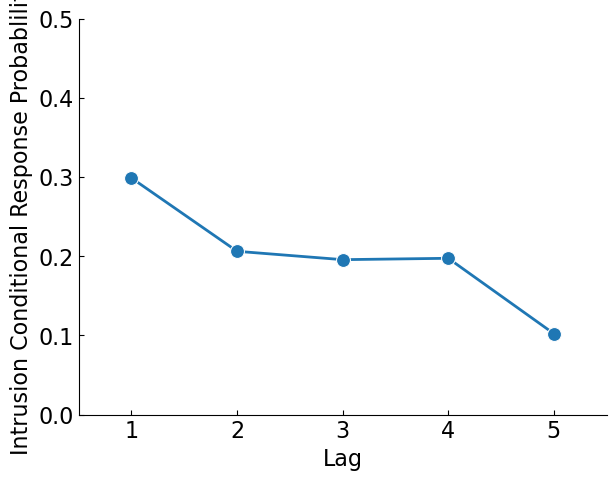

In [68]:
# plot
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)

ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")
sns.lineplot(data=df_PLI_sess_lag, x="abs_list_lag", y="PLI_prob", linewidth=2, marker="o", markersize=10, errorbar=None)
plt.ylim([0, 0.5])
plt.xlim([0.5, 5.5])
plt.xticks(ticks=np.arange(1, 6))
plt.xlabel("Lag")
plt.ylabel("Intrusion Conditional Response Probablility")

if SAVEFIG:
    ax.set(xlabel=None, ylabel=None)
    plt.tick_params(labelleft=False)
    plt.savefig("simu7_fig/simu7_PLI.pdf")

### ILI

In [69]:
# pick out ILI
df_ILI = df_simu.query("intrusion_type == 'ILI'").copy()
df_ILI["pos_lag"] = df_ILI["pos_lag"].astype(int)
df_ILI["pos_lag"] = pd.Categorical(df_ILI["pos_lag"], categories=np.concatenate([np.arange(-11, 0), np.arange(1, 12)]), ordered=True)
df_ILI

,session,list,test_itemno,s_resp,s_rt,csim,test_item,correct_ans,study_pos,test_dir,correct,resp_study_list,resp_study_pos,list_lag,pos_lag,intrusion_type
16,0,2,173,492.0,2010.0,0.861439,BRIDE,414,10,0,False,2.0,11.0,0.0,1,ILI
17,0,2,492,688.0,2370.0,0.690248,DRAGON,845,11,0,False,2.0,1.0,0.0,-10,ILI
24,0,3,611,266.0,2660.0,0.852658,FUDGE,962,9,1,False,3.0,11.0,0.0,2,ILI
32,0,4,1185,780.0,4050.0,0.863077,REPTILE,1134,9,1,False,4.0,11.0,0.0,2,ILI
36,0,4,753,762.0,3530.0,0.755893,JEEP,1440,5,0,False,4.0,3.0,0.0,-2,ILI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127864,998,15,701,40.0,5000.0,0.723126,HELICOPTER,1368,9,0,False,15.0,10.0,0.0,1,ILI
127887,999,1,597,1388.0,3880.0,0.737598,FOUNTAIN,605,11,0,False,1.0,10.0,0.0,-1,ILI
127891,999,2,1260,289.0,3320.0,0.727882,SEAFOOD,531,0,0,False,2.0,7.0,0.0,7,ILI
127909,999,4,1599,1107.0,2770.0,0.753089,WEED,1535,8,0,False,4.0,9.0,0.0,1,ILI


In [70]:
# session-wise, calculate ILI probability for each lag
def get_ILI_prob(df_tmp):

    # get possible ILI count
    possible_ILI_cnt = {}
    for pair_pos in df_tmp.study_pos:
        l_bound = -pair_pos
        r_bound = 11 - pair_pos
        for i in np.arange(l_bound, r_bound + 1):
            if i in possible_ILI_cnt:
                possible_ILI_cnt[i] += 1
            else:
                possible_ILI_cnt[i] = 1

    # get ILI count
    df_tmp_lag = df_tmp.groupby("pos_lag")["test_item"].count().to_frame(name="ILI_cnt")

    # merge possible ILI count
    df_tmp_lag["possible_ILI_cnt"] = df_tmp_lag.index.map(possible_ILI_cnt).astype(float)
    df_tmp_lag["ILI_prob"] = df_tmp_lag["ILI_cnt"] / df_tmp_lag["possible_ILI_cnt"]

    return df_tmp_lag


df_ILI_sess_lag = df_ILI.groupby("session").apply(get_ILI_prob).reset_index()
df_ILI_sess_lag = df_ILI_sess_lag.query("pos_lag > -6 and pos_lag < 6").copy()
df_ILI_sess_lag

,session,pos_lag,ILI_cnt,possible_ILI_cnt,ILI_prob
6,0,-5,0,5.0,0.000000
7,0,-4,0,6.0,0.000000
8,0,-3,0,6.0,0.000000
9,0,-2,1,7.0,0.142857
10,0,-1,1,7.0,0.142857
...,...,...,...,...,...
21879,999,1,1,3.0,0.333333
21880,999,2,0,2.0,0.000000
21881,999,3,0,2.0,0.000000
21882,999,4,0,1.0,0.000000


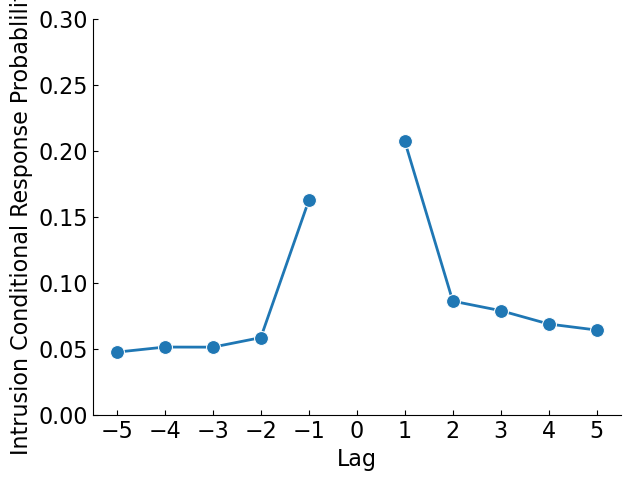

In [71]:
# plot
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)

ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")

sns.lineplot(data=df_ILI_sess_lag.query("-6 < pos_lag < 0"), x="pos_lag", y="ILI_prob", linewidth=2, marker="o", markersize=10, color="C0", errorbar=None)
sns.lineplot(data=df_ILI_sess_lag.query("0 < pos_lag < 6"), x="pos_lag", y="ILI_prob", linewidth=2, marker="o", markersize=10, color="C0", errorbar=None)
plt.ylim([0, 0.3])
plt.xticks(ticks=np.arange(-5, 6))
plt.xlabel("Lag")
plt.ylabel("Intrusion Conditional Response Probablility")

if SAVEFIG:
    ax.set(xlabel=None, ylabel=None)
    plt.tick_params(labelleft=False)
    plt.savefig("simu7_fig/simu7_ILI.pdf")

### Err Check

In [72]:
lag_PLI_mean = df_PLI_sess_lag.groupby("abs_list_lag").PLI_prob.mean().values
df_ILI_sess_lag["pos_lag_int"] = df_ILI_sess_lag["pos_lag"].astype(int)  # avoid nan from category vairables
lag_ILI_mean = df_ILI_sess_lag.groupby("pos_lag_int").ILI_prob.mean().values
lag_PLI_mean, lag_ILI_mean

(array([0.29869836, 0.20616865, 0.19561404, 0.19734012, 0.10217883]),
 array([0.04729969, 0.05115418, 0.05108515, 0.0583068 , 0.16223246,
        0.20698223, 0.08594921, 0.0787289 , 0.0686038 , 0.06403108]))

In [73]:
np.any(np.diff(lag_PLI_mean) >= 0)

True

In [74]:
np.any(np.diff(lag_ILI_mean[:5]) <= 0), np.any(np.diff(lag_ILI_mean[5:]) >= 0)

(True, False)

In [75]:
with open("simu7_data/simu7_gt.pkl", "rb") as f:
    p_correct_mean_gt = pickle.load(f)
    p_correct_se_gt = pickle.load(f)
    p_PLI_mean_gt = pickle.load(f)
    p_PLI_se_gt = pickle.load(f)
    p_ILI_mean_gt = pickle.load(f)
    p_ILI_se_gt = pickle.load(f)
    lag_PLI_mean_gt = pickle.load(f)
    lag_PLI_se_gt = pickle.load(f)
    lag_ILI_mean_gt = pickle.load(f)
    lag_ILI_se_gt = pickle.load(f)

In [76]:
lag_PLI_mean_gt, lag_ILI_mean_gt

(array([0.32678571, 0.24033447, 0.16269841, 0.19515306, 0.07502834]),
 array([0.04853509, 0.08652118, 0.08350867, 0.09478323, 0.1486024 ,
        0.21154655, 0.08574898, 0.10563333, 0.08867651, 0.0508634 ]))

In [77]:
wls_p_correct = (p_correct_mean - p_correct_mean_gt) ** 2 / (p_correct_se_gt**2)
wls_p_PLI = (p_PLI_mean - p_PLI_mean_gt) ** 2 / (p_PLI_se_gt**2)
wls_p_ILI = (p_ILI_mean - p_ILI_mean_gt) ** 2 / (p_ILI_se_gt**2)
wls_lag_PLI = np.nanmean((lag_PLI_mean - lag_PLI_mean_gt) ** 2 / (lag_PLI_se_gt**2))
wls_lag_ILI = np.nanmean((lag_ILI_mean - lag_ILI_mean_gt) ** 2 / (lag_ILI_se_gt**2))
wls_p_correct, wls_p_PLI, wls_p_ILI, wls_lag_PLI, wls_lag_ILI

(0.00047560418831729223,
 0.00034714882290360065,
 6.321812542664142e-05,
 0.009159331856757524,
 0.02690830156428093)

In [78]:
err = wls_p_correct + wls_p_PLI + wls_p_ILI + wls_lag_PLI + wls_lag_ILI
err

0.03695360455768599